<div style="margin-bottom: 120px;">
    <div style="float:left;">
        <br/>
        <img src="img/udc.png" width="300"/>
    </div>
</div>

<h1 style="color: #d60e8c; text-align:center;">Procesado de datos</h1>


<h1>Contenidos</h1>

<div class="alert alert-block alert-info" 
     style="margin-top: 20px; padding-top:0px; padding-bottom:0px;border: 1px solid #d60e8c; border-radius: 20px; background:transparent;">
    <ol>
        <li><a href="#intro">Introducción</a></li>
        <li><a href="#about_dataset">Descripción del conjunto de datos</a></li>
        <li><a href="#analysis">Lectura y análisis de los datos </a></li>
        <li><a href="#division">División del conjunto de datos en datos en entrada y salida</a></li>
        <li><a href="#split">División de los datos para entrenamiento y prueba</a></li>
        <li><a href="#oversampling">Balanceo de datos</a></li>
        <li><a href="#scale">Normalización</a></li>        
        <li><a href="#pca">PCA</a></li>        
        <li><a href="#classification">Ejercicio</a></li>
    </ol>
</div>
<br>

<a name="intro"></a>
<h1 style="color: #d60e8c;">Introducción</h1>
<hr style="border: 0.5px solid #d60e8c;">

El objetivo de esta práctica es realizar un informe técnico que analice el funcionamiento de al menos dos técnicas de aprendizaje supervisado sobre un conjunto de datos etiquetados, de modo que se pueda realizar una caracterización objetiva de su funcionamiento en base a los resultados obtenidos.

## Importamos las librerías

Comenzamos importando las librerías que utilizaremos:

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn import preprocessing
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

<a name="about_dataset"></a>
<h1 style="color: #d60e8c;">Descripción del conjunto de datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

Utilizaremos un conjunto de datos sobre setas laminadas. Todos los atributos se definen mediante palabras o texto. Los datos fueron recolectados 
de la "Guía de campo de la Sociedad Audubon". 
<br><br>
El conjunto de datos original incluye descripciones de muestras hipotéticas correspondientes a 23 especies de setas con láminas de la familia Agaricus y Lepiota (pp. 500-525). Cada especie se identifica como claramente comestible o claramente venenosa en función de las siguientes cualidades:
<ul>
    <li><b>poisonous</b>: si es una seta venenosa o comestible </li> 
    <li><b>cap-shape</b>: forma de la gorra de la seta</li>
    <li><b>cap-surface</b>: tipo de superficie de la gorra de la seta</li>
    <li><b>cap-color</b>: color de la gorra de la seta</li>
    <li><b>bruises</b>: hematomas</li>
    <li><b>odor</b>: olor</li>
    <li><b>gill-attachment</b>: fijación de las branquias </li>
    <li><b>gill-spacing</b>: separación entre las branquias </li>
    <li><b>gill-size</b> tamaño de las branquias</li>
    <li><b>gill-color</b>: color de las branquias</li>
    <li><b>stalk-shape</b>: forma del tallo</li>
    <li><b>stalk-root</b>: raiz del tallo </li>    
    <li><b>stalk-surface-above-ring</b>: superficie del tallo por encima del anillo</li>
    <li><b>stalk-surface-below-ring</b>: superficie del tallo por debajo del anillo</li>
    <li><b>stalk-color-above-ring</b>: color del tallo por encima del anillo</li>
    <li><b>stalk-color-below-ring</b>: color del tallo por debajo del anillo</li>
    <li><b>veil-type</b>: tipo de velo </li>   
    <li><b>veil-color</b>: color del velo </li>
    <li><b>ring-number</b>: numero de anillos </li> 
    <li><b>ring-type</b>: tipo de anillos </li>
    <li><b>spore-print-color</b>: color de la huella de esporas </li>  
    <li><b>population</b>: rareza y facilidad para encontrarlas </li> 
    <li><b>habitat</b>: habitat en el que crecen</li>       

</ul>

<a name="analysis"></a>
<h1 style="color: #d60e8c;">Lectura y análisis de los datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

El archivo con el conjunto de datos tiene valores perdidos en el dataset, con lo que, cuando leemos el archivo, indicamos que existen valores perdidos con <code>na_values=["?"]</code> (de esta forma, estamos indicando que los valores perdidos están representados por el carácter "?"). Así, en la lectura del archivo, esos valores las celdas que contengan el valor "?" serán convertidas a valores nulos, posteriormente se filtrarán.

In [47]:
df_orig=pd.read_csv('mushroms1.csv', na_values=["?"])
df_orig.head()

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
1,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,WHITE,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
2,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS
3,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,PINK,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,BROWN,SEVERAL,WOODS
4,EDIBLE,CONVEX,SMOOTH,WHITE,BRUISES,ALMOND,FREE,CROWDED,NARROW,BROWN,...,SMOOTH,WHITE,WHITE,PARTIAL,WHITE,ONE,PENDANT,PURPLE,SEVERAL,WOODS


## Eliminación de filas con información incompleta

1. Se consultan las dimensiones del conjunto de datos:

In [48]:
df_orig.shape

(8417, 23)

2. Se obtienen los valores nulos que tenememos en cada columna: sabemos que existen porque en la lectura del archivo, hemos indicado que el conjunto de datos contiene valores perdidos para que los convirtiese en nulos en la lectura. Vemos que tenemos bastantes valores nulos en la columna **stalk-root** y 1 valor nulo en todas las columnas menos en la columna de **poisonous**.

In [49]:
df_orig.isnull().sum()

poisonous                      0
cap-shape                      1
cap-surface                    1
cap-color                      1
bruises                        1
odor                           1
gill-attachment                1
gill-spacing                   1
gill-size                      1
gill-color                     1
stalk-shape                    1
stalk-root                  2481
stalk-surface-above-ring       1
stalk-surface-below-ring       1
stalk-color-above-ring         1
stalk-color-below-ring         1
veil-type                      1
veil-color                     1
ring-number                    1
ring-type                      1
spore-print-color              1
population                     1
habitat                        1
dtype: int64

3. Se eliminan las filas que contienen algún valor nulo en alguna de sus columnas, ya que tienen información incompleta.

In [50]:
df=df_orig.dropna(axis=0)

4. Se consultan las dimensiones del dataset tras eliminar las filas con valores nulos.

In [51]:
df.shape

(5936, 23)

5. Se consulta de nuevo los valores nulos para verificar que ya no existen. Ahora el resultado debería ser 0 para todas las columnas.

In [52]:
df.isnull().sum()

poisonous                   0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

6. Ahora se comprobará que tenemos unos valores de la columna de **poisonous** equilibrados entre setas comestibles y venenosas:

In [53]:
df['poisonous'].value_counts()

poisonous
EDIBLE       3768
POISONOUS    2168
Name: count, dtype: int64

<a name="division"></a>
<h1 style="color: #d60e8c;">Transformación de los valores del conjunto de datos de texto a número</h1>
<hr style="border: 0.5px solid #d60e8c;">

Para poder trabajar con el conjunto de datos que hemos analizado y ajustado anteriormente, es necesario pasar todos los valores que sean de texto en alguna columna a número para evitar errores y poder implementar el método utilizado en clase.

A continuación se incluye el código completo con el que se han ido transformando todos los valores a número, además de a qué número le corresponde cada palabra:

In [54]:
encoder = preprocessing.OrdinalEncoder(dtype=int)
df_encoded = encoder.fit_transform(df[['poisonous', "cap-shape","cap-surface","cap-color","bruises","odor",
                                      "gill-attachment","gill-spacing","gill-size","gill-color","stalk-shape","stalk-root",
                                      "stalk-surface-above-ring","stalk-surface-below-ring","stalk-color-above-ring",
                                      "stalk-color-below-ring","veil-type","veil-color","ring-number","ring-type",
                                      "spore-print-color","population","habitat"]])
encoder.categories_

[array(['EDIBLE', 'POISONOUS'], dtype=object),
 array(['BELL', 'CONICAL', 'CONVEX', 'FLAT', 'KNOBBED', 'SUNKEN'],
       dtype=object),
 array(['FIBROUS', 'GROOVES', 'SCALY', 'SMOOTH'], dtype=object),
 array(['BROWN', 'BUFF', 'CINNAMON', 'GRAY', 'PINK', 'RED', 'WHITE',
        'YELLOW'], dtype=object),
 array(['BRUISES', 'NO'], dtype=object),
 array(['ALMOND', 'ANISE', 'CREOSOTE', 'FOUL', 'MUSTY', 'NONE', 'PUNGENT'],
       dtype=object),
 array(['ATTACHED', 'FREE'], dtype=object),
 array(['CLOSE', 'CROWDED'], dtype=object),
 array(['BROAD', 'NARROW'], dtype=object),
 array(['BLACK', 'BROWN', 'CHOCOLATE', 'GRAY', 'GREEN', 'PINK', 'PURPLE',
        'WHITE', 'YELLOW'], dtype=object),
 array(['ENLARGING', 'TAPERING'], dtype=object),
 array(['BULBOUS', 'CLUB', 'EQUAL', 'ROOTED'], dtype=object),
 array(['FIBROUS', 'SCALY', 'SILKY', 'SMOOTH'], dtype=object),
 array(['FIBROUS', 'SCALY', 'SILKY', 'SMOOTH'], dtype=object),
 array(['BROWN', 'BUFF', 'CINNAMON', 'GRAY', 'PINK', 'WHITE', 'YELLOW'],

Este es el texto presente en el archivo .csv, y acontinuación se mostrarán las correspondencias numéricas:

In [55]:
df_encoded

array([[0, 2, 3, ..., 4, 4, 5],
       [0, 2, 3, ..., 1, 4, 5],
       [0, 2, 3, ..., 4, 4, 5],
       ...,
       [0, 3, 2, ..., 5, 4, 3],
       [0, 3, 2, ..., 5, 5, 3],
       [0, 3, 2, ..., 5, 4, 3]], shape=(5936, 23))

In [56]:
df["poisonous"] = df_encoded[:,0]
df["cap-shape"] = df_encoded[:,1]
df["cap-surface"] = df_encoded[:,2]
df["cap-color"] = df_encoded[:,3]
df["bruises"] = df_encoded[:,4]
df["odor"] = df_encoded[:,5]
df["gill-attachment"] = df_encoded[:,6]
df["gill-spacing"] = df_encoded[:,7]
df["gill-size"] = df_encoded[:,8]
df["gill-color"] = df_encoded[:,9]
df["stalk-shape"] = df_encoded[:,10]
df["stalk-root"] = df_encoded[:,11]
df["stalk-surface-above-ring"] = df_encoded[:,12]
df["stalk-surface-below-ring"] = df_encoded[:,13]
df["stalk-color-above-ring"] = df_encoded[:,14]
df["stalk-color-below-ring"] = df_encoded[:,15]
df["veil-type"] = df_encoded[:,16]
df["veil-color"] = df_encoded[:,17]
df["ring-number"] = df_encoded[:,18]
df["ring-type"] = df_encoded[:,19]
df["spore-print-color"] = df_encoded[:,20]
df["population"] = df_encoded[:,21]
df["habitat"] = df_encoded[:,22]
df.head()

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,2,3,6,0,0,1,1,1,7,...,3,5,5,0,0,1,3,4,4,5
1,0,2,3,6,0,0,1,1,1,7,...,3,5,5,0,0,1,3,1,4,5
2,0,2,3,6,0,0,1,1,1,5,...,3,5,5,0,0,1,3,4,4,5
3,0,2,3,6,0,0,1,1,1,5,...,3,5,5,0,0,1,3,1,4,5
4,0,2,3,6,0,0,1,1,1,1,...,3,5,5,0,0,1,3,4,4,5


<a name="division"></a>
<h1 style="color: #d60e8c;">División del conjunto de datos en datos en entrada y salida</h1>
<hr style="border: 0.5px solid #d60e8c;">


Se obtienen los atributos que caracterizan nuestro conjunto de datos:

In [57]:
df.columns

Index(['poisonous', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='str')

Se seleccionan las columnas que utilizaremos como entradas y las convertimos en un <b>array de NumPy</b>, para poder utilizarlo con los algoritmos de <b>scikit-learn</b>:

In [58]:
feature_df = df[df.columns[1:df.shape[1]]]
# Usando DataFrame Pandas
X = feature_df
X_readed = np.asarray(feature_df)
X_readed[0:5]
feature_df.shape

(5936, 22)

Y ahora los datos de salida, si la seta es venenosa o no:

In [59]:
y_readed = np.asarray(df['poisonous'])
y_readed[0:5]

array([0, 0, 0, 0, 0])

<a name="split"></a>
<h1 style="color: #d60e8c;">División en datos de entrenamiento y prueba</h1>
<hr style="border: 0.5px solid #d60e8c;">
El siguiente código, utiliza el 75% del conjunto de datos para entrenar el modelo y el 25% para test (valores por defecto si no se fijan el tamaño en los parámetros), ya que tenemos una gran cantidad de datos, se considera que no es necesario utilizar más del 75% de los datos para obtener unos resultados fiables.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_readed, y_readed, random_state = 1)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (4452, 22) (4452,)
Test set: (1484, 22) (1484,)


<a name="oversampling"></a>
<h1 style="color: #d60e8c;">Balanceo de datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

Como hemos podido observar anteriormente, la cantidad de valores en la columna de **poisonous** que se corresponden con setas comestibles y con setas venenosas es muy notable, siendo su diferencia del orden de 1600, siendo su representación de un 63% de setas comestibles y un 37% de setas venenosas. Esto puede influir en la capacidad del algoritmo para predecir correctamente la clase minoritaria, ya que al estar menos representada este puede ignorarla, haciendo que el calculo de la precisión del modelo no se asemeje completamente a la realidad.

Por lo tanto, para corregir esto, se utiliza la librería <a href="https://imbalanced-learn.org/stable/index.html"><b>imbalanced-learn</b></a> para realizar el balanceo del conjunto de datos, quitando muestras en los casos mayoritarios para obtener el conjunto final sobre el que se trabajará:

In [61]:

unique, counts = np.unique(y_train, return_counts=True)
sm = NearMiss()
X_train, y_train= sm.fit_resample(X_train, y_train)

print('\nBalanceado:', X_train.shape,  y_train.shape)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))


Balanceado: (3248, 22) (3248,)
{np.int64(0): np.int64(1624), np.int64(1): np.int64(1624)}


<a name="scale"></a>
<h1 style="color: #d60e8c;">Normalización</h1>
<hr style="border: 0.5px solid #d60e8c;">

Ahora se procederá a realizar la normalización del conjunto de datos, esto permitirá evitar que los algoritmos tengan un sesgo y aprendan mejor unas características que otras, buscando que estos datos sigan una distribución normal. Para ello, se transforman los datos para centrarlos eliminando el valor medio de cada característica y a continuación se escalan dividiendo las características por su desviación estándar. 

Como la librería <code>scikit-learn</code> dispone de un módulo para procesado de datos <code>preprocessing</code>. Vamos a utilizar <code>StandardScaler</code> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler">documentación</a>).  Que, una vez entrenado, se puede utilizar posteriormente sobre nuevos datos.


In [65]:
scaler = preprocessing.StandardScaler()
scaler.fit(X_train) # fit realiza los cálculos y los almacena

X_train = scaler.transform(X_train) # aplica los cálculos sobre el conjunto de datos de entrada para escalarlos
X_train[0:5]

array([[-0.61256489,  1.32402557,  0.89811178, -0.80439967, -1.8604143 ,
         0.07670837,  3.7466034 ,  2.35270297,  0.45057752,  1.0642523 ,
        -0.44374431,  0.61386886,  0.61645384,  0.78342452,  0.78692135,
         0.        , -0.04301987, -0.05786911,  0.68279868, -0.22738203,
        -0.09017986,  0.76378048],
       [-0.61256489, -1.22765662,  0.89811178, -0.80439967, -1.8604143 ,
         0.07670837,  3.7466034 ,  2.35270297, -1.34564929,  1.0642523 ,
        -0.44374431,  0.61386886,  0.61645384,  0.78342452,  0.78692135,
         0.        , -0.04301987, -0.05786911,  0.68279868, -0.22738203,
        -0.09017986,  0.76378048],
       [ 0.88563599, -1.22765662,  0.89811178, -0.80439967, -1.8604143 ,
         0.07670837,  3.7466034 ,  2.35270297, -1.34564929,  1.0642523 ,
        -0.44374431,  0.61386886,  0.61645384,  0.78342452,  0.78692135,
         0.        , -0.04301987, -0.05786911,  0.68279868, -0.22738203,
        -0.09017986,  0.76378048],
       [-0.61256489

<a name="pca"></a>
<h1 style="color: #d60e8c;">PCA</h1>
<hr style="border: 0.5px solid #d60e8c;">

Aplicando el Análisis de componentes principales (PCA) se tratará de buscar conjuntos de ejes de coordenadas en los que algunas de las dimensiones no sean necesarias utilizando algoritmos que centren los en el origen de coordenadas restando la media.

Para aplicar el Análisis de componentes principales (PCA) se utilizará el algoritmo <code>PCA</code> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html?highlight=pca#sklearn.decomposition.PCA">documentación del algoritmo</a>) implementado la librería <code>scikit-learn</code> sobre el conjunto de datos. Antes de utilizar PCA para extraer **n** componentes principales, lo utilizaresmos sin parámetros de forma que podemos analizar el porcentaje de varianza de todos los componentes utilizando "explained_variance_ratio_", que devuelve una lista, en este caso con 22 elementos porque vamos a usar los trece atributos, donde cada elemento de la lista indica el porcentaje de variabilidad que representa ese componente y, como utilizamos todos los componentes, la suma de todos los porcentajes, es decir, la suma de todos los elementos de la lista dará 1 como resultado.


In [69]:
mypca = PCA()
mypca.fit(X_train)

mypca.explained_variance_ratio_

array([0.24185777, 0.14224062, 0.08659908, 0.08088857, 0.06401374,
       0.05767656, 0.0447481 , 0.04121977, 0.03572028, 0.03225732,
       0.03128393, 0.02815225, 0.02269381, 0.01785345, 0.01776416,
       0.01579183, 0.01457732, 0.0113402 , 0.00863417, 0.00272329,
       0.00196379, 0.        ])

In [70]:
mypca.explained_variance_ratio_.sum()  # Suma todos los elementos de la lista

np.float64(0.9999999999999997)

A partir de <code>explained_variance_ratio_</code>, podemos calcular la varianza acumulada de los componentes:</li>   


In [71]:
print("\n Varianza que aporta cada componente:")
variance = mypca.explained_variance_ratio_
print(variance)

print("\n Varianza acumulada:")
acumvar = variance.cumsum()

for i in range(len(acumvar)):
    print(f" {(i+1):2} componentes: {acumvar[i]:.8f} ")



 Varianza que aporta cada componente:
[0.24185777 0.14224062 0.08659908 0.08088857 0.06401374 0.05767656
 0.0447481  0.04121977 0.03572028 0.03225732 0.03128393 0.02815225
 0.02269381 0.01785345 0.01776416 0.01579183 0.01457732 0.0113402
 0.00863417 0.00272329 0.00196379 0.        ]

 Varianza acumulada:
  1 componentes: 0.24185777 
  2 componentes: 0.38409839 
  3 componentes: 0.47069747 
  4 componentes: 0.55158604 
  5 componentes: 0.61559978 
  6 componentes: 0.67327634 
  7 componentes: 0.71802444 
  8 componentes: 0.75924421 
  9 componentes: 0.79496449 
 10 componentes: 0.82722181 
 11 componentes: 0.85850574 
 12 componentes: 0.88665799 
 13 componentes: 0.90935180 
 14 componentes: 0.92720524 
 15 componentes: 0.94496941 
 16 componentes: 0.96076123 
 17 componentes: 0.97533856 
 18 componentes: 0.98667875 
 19 componentes: 0.99531292 
 20 componentes: 0.99803621 
 21 componentes: 1.00000000 
 22 componentes: 1.00000000 


<h3>Projección PCA con 2 componentes</h3>
Ahora vamos a utilizar PCA para extraer dos componentes y visualizar el resultado en una gráfica, así como calcular la pérdida de información respecto al conjunto original con los 22 atributos de entrada.

In [72]:
mypca2 = PCA(n_components=2)
mypca2.fit(X_train)
values_proj2 = mypca2.transform(X_train)


Con la función <code>inverse_transform</code> se reconstruye el conjunto de datos de los <code>n</code> componentes principales (2 componentes, en este caso), y calcula la pérdida de información respecto al conjunto original. Para calcular esa pérdida, se puede calcular el promedio de las diferencias elevadas al cuadrado entre cada elemento del conjunto reconstruido y el original. Si sumamos el valor de pérdida obtenido al porcentaje de la varianza acumulada con dos componentes, vemos que el resultado es 1.

In [73]:
X_projected2 = mypca2.inverse_transform(values_proj2)
loss2 = ((X_train - X_projected2) ** 2).mean()
print("Projection loss (2 components): " + str(loss2))

Projection loss (2 components): 0.5879060837007153


Vamos ahora a mostrar la gráfica de la distribución de los datos origninales con los dos primeros atributos y la proyección PCA con 2 componentes componentes principales. En ambos casos, se utilizan dos dimensiones:

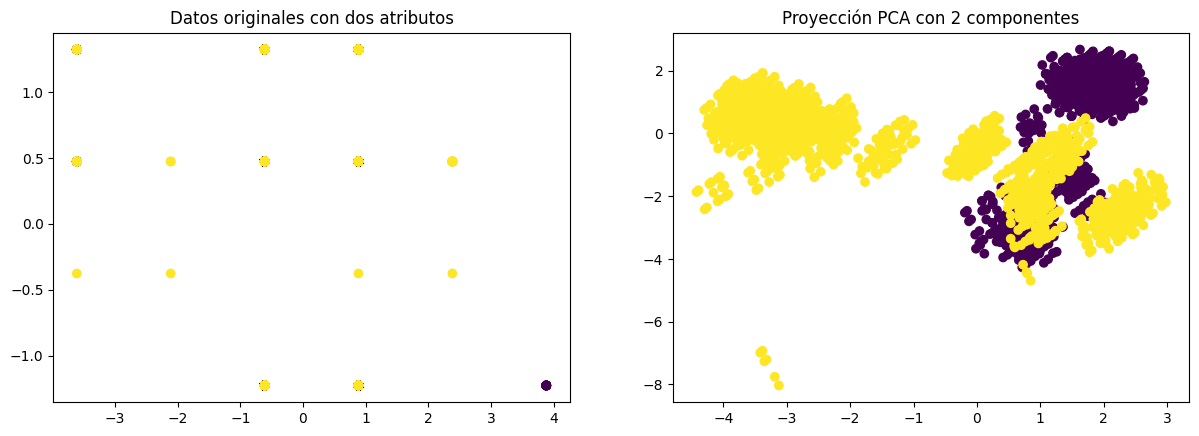

In [74]:
plt.figure()
plt.subplot(1,2,1) # 1 - numrows, 2 - numcols, 1 - index
plt.title("Datos originales con dos atributos")
plt.scatter(X_train[: ,0] , X_train[: ,1] ,marker='o' ,c=y_train)
plt.subplot(1,2,2) # 1 - numrows, 2 - numcols, 2 - index
plt.scatter(values_proj2[: ,0] , values_proj2[: ,1],marker='o' ,c=y_train)
plt.title("Proyección PCA con 2 componentes")
plt.subplots_adjust(right=1.9) # Distancia a la derecha
plt.show()


**Conclusión:**<br>
Si intentamos visualizar los datos con dos variables al azar, el resultado que obtenemos no nos proporciona información sobre la distribución en clases de los datos, como ocurre en la gráfica de la izquierda. Sin embargo, si visualizamos los datos en base a dos componentes, obtenemos información relevante y podemos visualizar ya cierta separación entre las clases, aunque, en este caso, tras ver los resultados de las varianza obtenida con cada componente, para obtener una mejor separación entre  clases necesitaríamos llegar a 8-9 componentes, pero no podemos visualizarlo gráficamente.

Sin embargo, si se visualizan los datos en base a 2 componentes, para este caso, todavía se pueden observar datos bastante mezclados con un **projection loss** de 0.5879, un valor de perdidas demasiado alto, es por ello, que se decide realizar cálculos con más componentes para evitar perdidas muy grandes de datos. Además, en este caso, tras ver los resultados de la varianza obtenida con cada componente, para obtener una mejor separación entre clases necesitaríamos llegar a 12-13 componentes, pero no podemos visualizarlo gráficamente.

<h3>Projección con 13 componentes</h3>

In [77]:
mypca11 = PCA(n_components=13)
mypca11.fit(X_train)
values_proj11 = mypca11.transform(X_train)

X_projected13 = mypca11.inverse_transform(values_proj11)
loss11 = ((X_train - X_projected11) ** 2).mean()

print("Projection loss (11 components): " + str(loss11))




Projection loss (11 components): 0.0865278299371513


Una vez realizadas varias pruebas, se puede observar que, a partir de 13 componentes, las perdidas de información se reducen a valores inferiores al 10%, por lo que se considera recomendable aplicar un PCA a como mínimo 13 componentes.

<a name="classification"></a>
# <font style="color:#d60e8c;">Clasificación</font>
<hr style="border: 0.5px solid #d60e8c;">

## KNN

### Entrenamiento
Utilizaremos el algoritmo <code>KNeighborsClassifier</code> de <b>scikit-learn</b> (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html?highlight=kneighborsclassifier#sklearn.neighbors.KNeighborsClassifier">documentación del algoritmo</a>).

In [41]:
k = 5    # Número de vecinos

# Creamos nuestra instancia de nuestro algoritmo KNN con 4 vecinos
neigh = KNeighborsClassifier(n_neighbors = k, weights='distance')

ini = time.time() 
#Entrenamiento del modelo, llamando a su método fit 
neigh.fit(X_train,y_train)
print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms") 

Tiempo entrenamiento = 2.672 ms


### Predicción
Ahora podemos utilizar nuestro modelo entrenado para realizar predicciones, para ello llamamos al método <code>predict</code> con el conjunto de valores que hemos reservado para test:

In [66]:
ini = time.time() 
y_predict_knn = neigh.predict(X_test)
print(f"Tiempo de predicción = {(time.time() - ini)*1000:.3f} ms") 

y_predict_knn[0:5] # muestra del resultado de la predicción

Tiempo de predicción = 57.726 ms


array([0, 0, 0, 1, 0])

Ahora, será importante determinar el número de vecinos que queremos considerar a la hora de hacer predicciones. Se estudiarán dos casos, un valor de k alto, muy estable y poco sensible al ruido aunque puede perder detalles, o un valor de k bajo que es un modelo flexible y que se adapta muy bien a variaciones y detalles, pero es muy sensible al ruido.

In [80]:
Score = np.zeros(99)
Posicion = np.zeros(99)
for i in range(1,100):
    k = i   # Número de vecinos
    
    # Creamos nuestra instancia de nuestro algoritmo KNN con K vecinos
    neigh = KNeighborsClassifier(n_neighbors = k)
    neigh.fit(X_train,y_train)
    y_predict_knn = neigh.predict(X_test)
    # print("Exactitud media obtenida con k-NN: " , neigh.score(X_test, y_test))
    
    Score[i-1] = neigh.score(X_test, y_test)
    Posicion[i-1] = i
    print("Exactitud media obtenida con k-NN para k={i}: ".format(i=i), neigh.score(X_test, y_test))

Exactitud media obtenida con k-NN para k=1:  0.4777628032345013
Exactitud media obtenida con k-NN para k=2:  0.5316711590296496
Exactitud media obtenida con k-NN para k=3:  0.5080862533692723
Exactitud media obtenida con k-NN para k=4:  0.5397574123989218
Exactitud media obtenida con k-NN para k=5:  0.5053908355795148
Exactitud media obtenida con k-NN para k=6:  0.5336927223719676
Exactitud media obtenida con k-NN para k=7:  0.5121293800539084
Exactitud media obtenida con k-NN para k=8:  0.545822102425876
Exactitud media obtenida con k-NN para k=9:  0.5303234501347709
Exactitud media obtenida con k-NN para k=10:  0.5471698113207547
Exactitud media obtenida con k-NN para k=11:  0.5154986522911051
Exactitud media obtenida con k-NN para k=12:  0.5262803234501348
Exactitud media obtenida con k-NN para k=13:  0.5141509433962265
Exactitud media obtenida con k-NN para k=14:  0.5316711590296496
Exactitud media obtenida con k-NN para k=15:  0.522911051212938
Exactitud media obtenida con k-NN pa

In [79]:
Valor_maximo = np.max(Score)

print(f"El valor máximo de exactitud es de: {Valor_maximo}")
print(f"Y está situado en la posición: {Score.argmax()}")

El valor máximo de exactitud es de: 0.4440700808625337
Y está situado en la posición: 97


Aquí se puede observar un detalle muy llamativo, si se decide realizar una normalización de los datos, la exactitud que es capaz de conseguir el modelo es de un máximo del 57%, mientras que sin realizar esta normalización este valor asciende al 98%.

<a name="classification"></a>
<div class="alert alert-block alert-info" 
     style="border: 0px solid #d60e8c; border-radius: 10px; background:#d60e8c; color: white;">
      <h2>EJERCICIO</h2>
    <hr style="border: 0.5px solid #ffffff;">
   <ul style="margin-bottom: 20px;">
       <li>
          Utiliza  dos algoritmos de clasificación supervisada sobre el conjunto de datos original y sobre dos proyecciones PCA (las que que consideres más relevantes para su análisis, una de ellas debe ser diferente a los ejemplos de este cuaderno). Para cada algoritmo de clasificación:
           <ol>
               <li>Crea el modelo, entrénalo y calcula su exactitud. Realiza varias pruebas con distintos parámetros para determinar
                  la mejor configuración. Muestra la matriz de confusión de cada uno.</li>
               <li> Realiza las pruebas con el conjunto datos sin balancear y balanceado. Analiza los resultados obtenidos en ambos casos. ¿Cómo afecta el balanceao a los resultados?¿Merece la pena utilizarlo?</li>               
               <li>Extrae conclusiones sobre los resultados obtenidos, comparando los resultados obtenidos sobre el conjunto de datos original con los 13 atributos y conjuntos de datos transformados con PCA. ¿Merece la pena utilizar PCA en este conjunto de datos? Razona la respuesta.</li>               
           </ol>           
       </li>    
    </ul>
    <font style="font-weight: bold;">Se recomienda realizar este ejercicio como un programa en Visual Studio Code. Servirá de preparación para las prácticas entregables.</font>
</div>

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn import preprocessing
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

df_orig=pd.read_csv('mushroms1.csv', na_values=["?"])
df_orig.head()
df_orig.isnull().sum()
df=df_orig.dropna(axis=0)
df.isnull().sum()

#Pasamos de texto a numero
encoder = preprocessing.OrdinalEncoder(dtype=int)
df_encoded = encoder.fit_transform(df[['poisonous', "cap-shape","cap-surface","cap-color","bruises","odor",
                                      "gill-attachment","gill-spacing","gill-size","gill-color","stalk-shape","stalk-root",
                                      "stalk-surface-above-ring","stalk-surface-below-ring","stalk-color-above-ring",
                                      "stalk-color-below-ring","veil-type","veil-color","ring-number","ring-type",
                                      "spore-print-color","population","habitat"]])
encoder.categories_
df_encoded
df["poisonous"] = df_encoded[:,0]
df["cap-shape"] = df_encoded[:,1]
df["cap-surface"] = df_encoded[:,2]
df["cap-color"] = df_encoded[:,3]
df["bruises"] = df_encoded[:,4]
df["odor"] = df_encoded[:,5]
df["gill-attachment"] = df_encoded[:,6]
df["gill-spacing"] = df_encoded[:,7]
df["gill-size"] = df_encoded[:,8]
df["gill-color"] = df_encoded[:,9]
df["stalk-shape"] = df_encoded[:,10]
df["stalk-root"] = df_encoded[:,11]
df["stalk-surface-above-ring"] = df_encoded[:,12]
df["stalk-surface-below-ring"] = df_encoded[:,13]
df["stalk-color-above-ring"] = df_encoded[:,14]
df["stalk-color-below-ring"] = df_encoded[:,15]
df["veil-type"] = df_encoded[:,16]
df["veil-color"] = df_encoded[:,17]
df["ring-number"] = df_encoded[:,18]
df["ring-type"] = df_encoded[:,19]
df["spore-print-color"] = df_encoded[:,20]
df["population"] = df_encoded[:,21]
df["habitat"] = df_encoded[:,22]
df.head()

df.shape
df['poisonous'].value_counts()
df.columns
feature_df = df[df.columns[1:df.shape[1]]]
# Usando DataFrame Pandas
X = feature_df

# Usando array NumPy
#X = np.asarray(feature_df)
X[0:5] # solo para inspeccionar una muestra de X
# Usando DataFrame Pandas
y = df['poisonous']

# Usando array NumPy
#y = np.asarray(df['Class'])
y[0:5] # solo para inspeccionar una muestra de y

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Training set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

print ('Conjunto entrenamiento original', X_train.shape,  y_train.shape)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

# Balanceo de datos: ejemplo de oversampling
#sm = SMOTE(random_state=1)
#X_train, y_train= sm.fit_resample(X_train, y_train)

# Balanceo de datos: ejemplo de undersampling
sm = NearMiss()
X_train, y_train= sm.fit_resample(X_train, y_train)


print('\nBalanceado:', X_train.shape,  y_train.shape)
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))



Score = np.zeros(99)
Posicion = np.zeros(99)
for i in range(1,100):
    k = i   # Número de vecinos
    
    # Creamos nuestra instancia de nuestro algoritmo KNN con K vecinos
    neigh = KNeighborsClassifier(n_neighbors = k)
    neigh.fit(X_train,y_train)
    y_predict_knn = neigh.predict(X_test)
    # print("Exactitud media obtenida con k-NN: " , neigh.score(X_test, y_test))
    
    Score[i-1] = neigh.score(X_test, y_test)
    Posicion[i-1] = i
    print("Exactitud media obtenida con k-NN para k={i}: ".format(i=i), neigh.score(X_test, y_test))

Training set: (4748, 22) (4748,)
Test set: (1188, 22) (1188,)
Conjunto entrenamiento original (4748, 22) (4748,)
{np.int64(0): np.int64(3008), np.int64(1): np.int64(1740)}

Balanceado: (3480, 22) (3480,)
{np.int64(0): np.int64(1740), np.int64(1): np.int64(1740)}
Exactitud media obtenida con k-NN para k=1:  0.9806397306397306
Exactitud media obtenida con k-NN para k=2:  0.9806397306397306
Exactitud media obtenida con k-NN para k=3:  0.9747474747474747
Exactitud media obtenida con k-NN para k=4:  0.9747474747474747
Exactitud media obtenida con k-NN para k=5:  0.9705387205387206
Exactitud media obtenida con k-NN para k=6:  0.9688552188552189
Exactitud media obtenida con k-NN para k=7:  0.9562289562289562
Exactitud media obtenida con k-NN para k=8:  0.9570707070707071
Exactitud media obtenida con k-NN para k=9:  0.9562289562289562
Exactitud media obtenida con k-NN para k=10:  0.9562289562289562
Exactitud media obtenida con k-NN para k=11:  0.9537037037037037
Exactitud media obtenida con k-

In [ ]:
for i in range(1, 100):
    k = i

    # Creamos nuestra instancia del modelo
    neigh = KNeighborsClassifier(n_neighbors = k)

    ini = time.time() 
    #Entrenamiento del modelo, llamando a su método fit 
    neigh.fit(X_train,y_train)
    #print(f"Tiempo entrenamiento = {(time.time() - ini)*1000:.3f} ms") 

    ini = time.time() 
    y_predict_knn = neigh.predict(X_test)
    #print(f"Tiempo de predicción = {(time.time() - ini)*1000:.3f} ms") 

    y_predict_knn[0:5] # muestra del resultado de la predicción

    print("Exactitud media obtenida con k-NN para k={i}: ".format(i=i), neigh.score(X_test, y_test))

<br/><br/>
<hr style="border: 0.5px solid #d60e8c;">
<div style="text-align:right;">
MASTER UNIVERSITARIO EN INGENIERÍA INDUSTRIAL
</div>